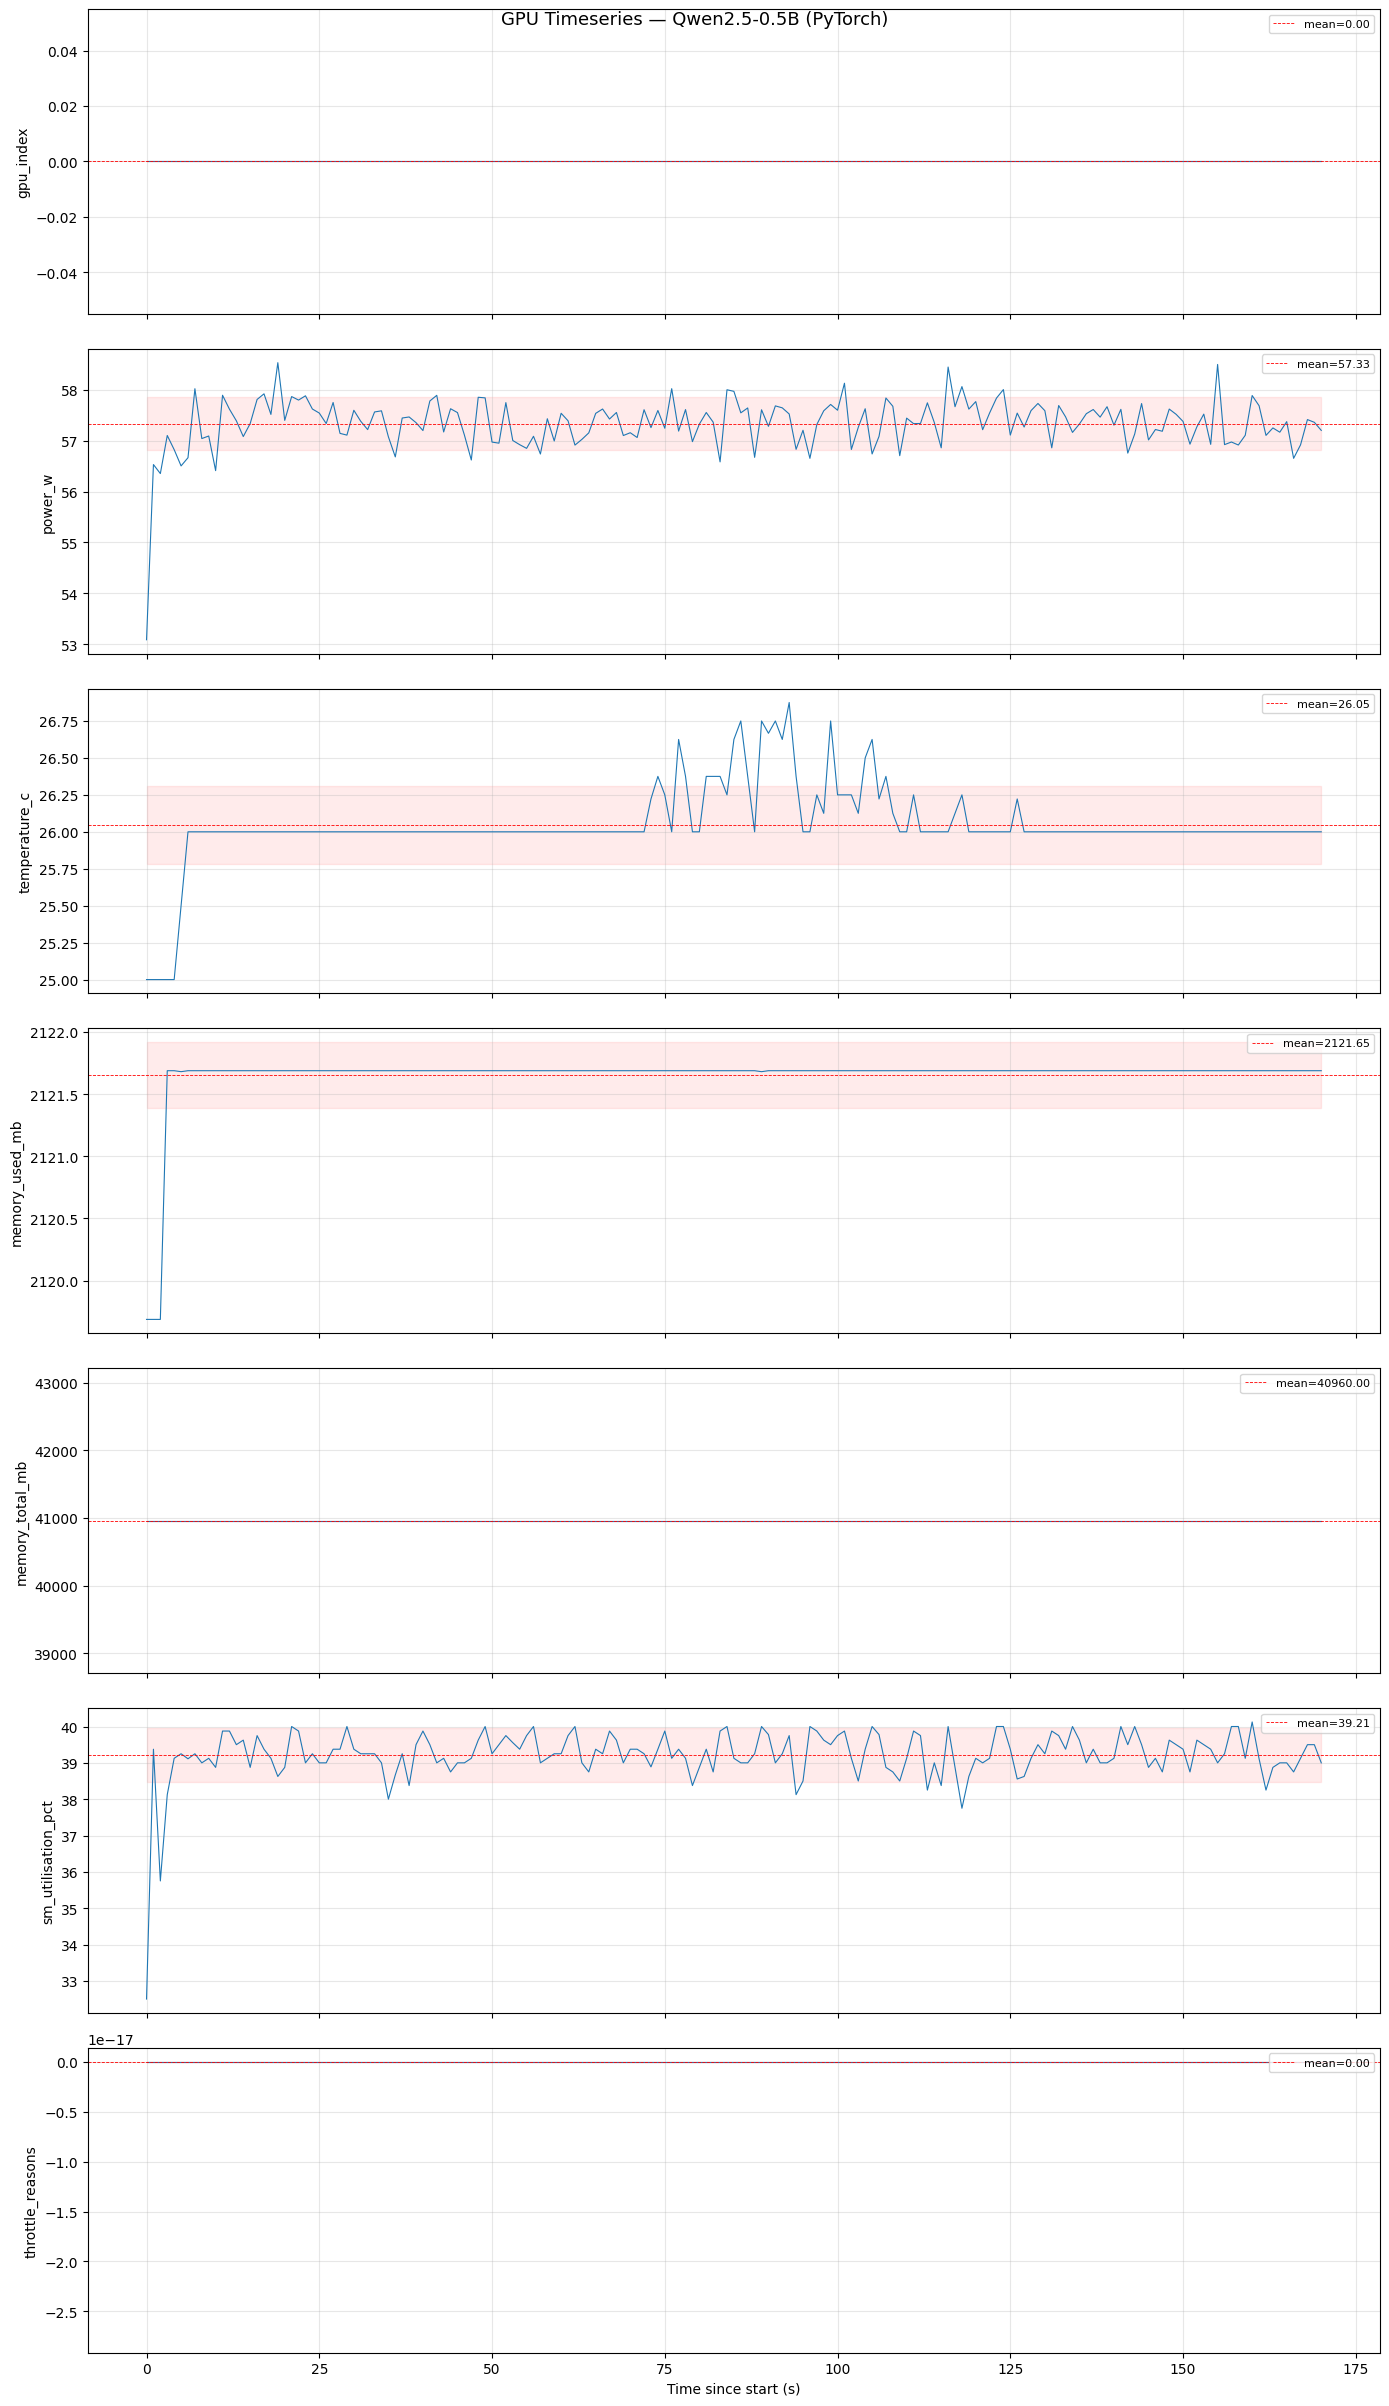


Sampling interval (s):
count    170.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: timestamp_s, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_parquet(
    "/home/h.baker@hertie-school.lan/workspace/llm-efficiency-measurement-tool/"
    "results/full-suite-all-backends_2026-03-26T11-25-15/"
    "qwen-qwen2.5-0.5b_pytorch_2026-03-26T12-29/timeseries.parquet"
)

# Relative time from start
t = df["timestamp_s"] - df["timestamp_s"].iloc[0]

# Detect which metric columns exist
metric_cols = [c for c in df.columns if c != "timestamp_s"]
n = len(metric_cols)

fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, metric_cols):
    ax.plot(t, df[col], linewidth=0.8)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
    # shade mean ± 1 std
    mean, std = df[col].mean(), df[col].std()
    ax.axhline(mean, color="red", linestyle="--", linewidth=0.6, label=f"mean={mean:.2f}")
    ax.fill_between(t, mean - std, mean + std, alpha=0.08, color="red")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time since start (s)")
fig.suptitle("GPU Timeseries — Qwen2.5-0.5B (PyTorch)", fontsize=13)
fig.tight_layout()
plt.show()

# Sampling interval summary
print("\nSampling interval (s):")
print(t.diff().describe())
